<a href="https://colab.research.google.com/github/LaxmikantRakhade/Machine_Learning_Practicals/blob/main/Lab_2_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Laxmikant Rakhade (CS23128)**

**Lab-2 Assignment-1:- To implement linear regression for predicting continuous target variables and model performance using appropreate matrics.**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
from google .colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path= "/content/drive/MyDrive/ML_DATASETS/insurance[1] - insurance[1].csv"
df=pd.read_csv(path)
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
x=df.drop('charges',axis=1)
y=df['charges']

In [ ]:
x

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


In [ ]:
y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [ ]:
X_train.shape

(1070, 6)

In [ ]:
X_test.shape

(268, 6)

In [ ]:
y_test.shape

(268,)

In [ ]:
X_train_encoded = pd.get_dummies(X_train, columns=['sex', 'smoker', 'region'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['sex', 'smoker', 'region'], drop_first=True)

model = LinearRegression()
model.fit(X_train_encoded, y_train)

LinearRegression()

In [ ]:
# prediction
y_pred = model.predict(X_test_encoded)

In [ ]:
# model Evaluation
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

In [ ]:
print("\n model Evaluatiuon Metrics")
print("_____________________________")
print ("Mean Absolute Error (MAE): ",mae)
print ("Mean Squared Error (MSE): ",mse)
print ("Root Mean Squared Error (RMSE): ",rmse)
print("R2 Score:", r2)



 model Evaluatiuon Metrics
_____________________________
Mean Absolute Error (MAE):  4181.19447375365
Mean Squared Error (MSE):  33596915.85136145
Root Mean Squared Error (RMSE):  5796.284659276273
R2 Score: 0.7835929767120724


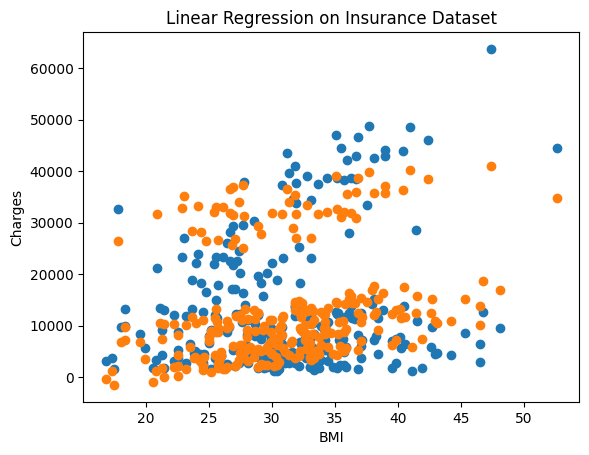

In [ ]:
# visualization (one frame)
plt.scatter(X_test['bmi'],y_test)
plt.scatter(X_test['bmi'],y_pred)
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("Linear Regression on Insurance Dataset")
plt.show()